# Fine Tuning - ConvNext

---


Brain Tumor MRI Classification

## Dependencias

In [12]:
%pip install -q transformers==5.0.0 timm scikit-learn matplotlib seaborn tqdm pillow

## Imports

In [13]:
import os, json, random, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from transformers import AutoModelForImageClassification

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Semilla global
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.cuda.manual_seed_all(SEMILLA)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [14]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo activo : {DEVICE}")

Dispositivo activo : cuda


## Montar Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive')

DIR_PROYECTO = Path('/content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri')
RUTA_CONFIG  = DIR_PROYECTO / 'dataset_config.json'

with open(RUTA_CONFIG, encoding='utf-8') as f:
    CFG = json.load(f)

DIR_SPLITS = Path(CFG['dir_splits'])
CLASES     = CFG['clases']
IMG_SIZE   = CFG['img_size']
MEDIA      = CFG['media_norm']
DESV       = CFG['desv_norm']
CLASE2IDX  = {c: i for i, c in enumerate(CLASES)}
IDX2CLASE  = {i: c for c, i in CLASE2IDX.items()}
N_CLASES   = len(CLASES)

print(f"Splits  : {DIR_SPLITS}")
print(f"Clases  : {CLASES}")
print(f"Conteo  :")
for split, conteo in CFG['conteo_splits'].items():
    print(f"  {split:<6} → {sum(conteo.values())} imagenes  {dict(conteo)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Splits  : /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/brain_tumor_splits
Clases  : ['glioma', 'meningioma', 'notumor', 'pituitary']
Conteo  :
  train  → 1120 imagenes  {'glioma': 280, 'meningioma': 280, 'notumor': 280, 'pituitary': 280}
  val    → 240 imagenes  {'glioma': 60, 'meningioma': 60, 'notumor': 60, 'pituitary': 60}
  test   → 240 imagenes  {'glioma': 60, 'meningioma': 60, 'notumor': 60, 'pituitary': 60}


## Dataset y Dataloaders

In [16]:
class TumorMRIDataset(Dataset):
    """Dataset de imagenes MRI de tumores cerebrales.

    Carga imagenes desde subdirectorios por clase y aplica
    las transformaciones indicadas.
    """

    EXTENSIONES = {'.jpg', '.jpeg', '.png', '.bmp'}

    def __init__(self, directorio: Path, transformaciones=None):
        self.transformaciones = transformaciones
        self.muestras = []

        for clase in CLASES:
            dir_clase = directorio / clase
            if not dir_clase.exists():
                raise FileNotFoundError(f"No se encontro: {dir_clase}")
            for ruta in dir_clase.rglob('*'):
                if ruta.suffix.lower() in self.EXTENSIONES:
                    self.muestras.append((ruta, CLASE2IDX[clase]))

        random.shuffle(self.muestras)

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, idx):
        ruta, etiqueta = self.muestras[idx]
        img = Image.open(ruta).convert('RGB')
        if self.transformaciones:
            img = self.transformaciones(img)
        return img, etiqueta


transform_train = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=MEDIA, std=DESV),
])

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEDIA, std=DESV),
])

ds_train = TumorMRIDataset(DIR_SPLITS / 'train', transform_train)
ds_val   = TumorMRIDataset(DIR_SPLITS / 'val',   transform_eval)
ds_test  = TumorMRIDataset(DIR_SPLITS / 'test',  transform_eval)

print(f"Muestras train: {len(ds_train)}  val: {len(ds_val)}  test: {len(ds_test)}")


Muestras train: 1120  val: 240  test: 240


## Espacio de Búsuqeda de Hiperparámetros

In [17]:
ESPACIO_HP = {
    'lr'          : [1e-5, 5e-5, 1e-4, 3e-4],
    'batch_size'  : [16],
    'dropout'     : [0.0, 0.1, 0.3],
    'scheduler'   : ['cosine', 'step'],
    'llrd'        : [0.75, 0.9],   # layer-wise lr decay rate
}

N_ENSAYOS    = 4
EPOCAS_MAX   = 30
PACIENCIA_ES = 5

random.seed(SEMILLA)
ensayos = []
for i in range(N_ENSAYOS):
    cfg = {k: random.choice(v) for k, v in ESPACIO_HP.items()}
    cfg['id'] = i + 1
    ensayos.append(cfg)

print("Configuraciones a evaluar:")
for e in ensayos:
    print(f"  Ensayo {e['id']}: lr={e['lr']:.0e}  dropout={e['dropout']}"
          f"  scheduler={e['scheduler']}  llrd={e['llrd']}")

Configuraciones a evaluar:
  Ensayo 1: lr=1e-05  dropout=0.3  scheduler=step  llrd=0.75
  Ensayo 2: lr=5e-05  dropout=0.3  scheduler=cosine  llrd=0.75
  Ensayo 3: lr=3e-04  dropout=0.0  scheduler=cosine  llrd=0.75
  Ensayo 4: lr=5e-05  dropout=0.3  scheduler=cosine  llrd=0.9


## Funciones auxiliares de entrenamiento

In [18]:
def construir_modelo(dropout: float) -> nn.Module:
    """Carga ConvNeXt-Base preentrenado y reemplaza la cabeza clasificadora."""
    modelo = AutoModelForImageClassification.from_pretrained(
        'facebook/convnext-base-224',
        num_labels=N_CLASES,
        ignore_mismatched_sizes=True,
    )
    # Reemplazar cabeza con dropout opcional
    dim_entrada = modelo.classifier.in_features
    if dropout > 0:
        modelo.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(dim_entrada, N_CLASES)
        )
    else:
        modelo.classifier = nn.Linear(dim_entrada, N_CLASES)

    return modelo.to(DEVICE)


def construir_optimizer_llrd(modelo, lr_base: float, decay_rate: float):
    """Construye AdamW con layer-wise learning rate decay.

    Las etapas mas profundas del encoder reciben lr_base.
    Cada etapa anterior recibe lr multiplicada por decay_rate.
    La cabeza clasificadora siempre recibe lr_base * 2 (mayor plasticidad).
    """
    grupos = []
    grupos.append({
        'params': modelo.classifier.parameters(),
        'lr'    : lr_base * 2,
        'name'  : 'classifier'
    })

    # Etapas del encoder en orden inverso (la ultima es la mas profunda)
    try:
        etapas = list(modelo.convnext.encoder.stages)
    except AttributeError:
        # Fallback: todos los parametros con lr base
        return optim.AdamW(modelo.parameters(), lr=lr_base, weight_decay=1e-4)

    lr_actual = lr_base
    for i, etapa in enumerate(reversed(etapas)):
        grupos.append({
            'params': etapa.parameters(),
            'lr'    : lr_actual,
            'name'  : f'stage_{len(etapas)-1-i}'
        })
        lr_actual *= decay_rate

    # Embeddings y capas iniciales
    try:
        grupos.append({
            'params': modelo.convnext.embeddings.parameters(),
            'lr'    : lr_actual,
            'name'  : 'embeddings'
        })
    except AttributeError:
        pass

    return optim.AdamW(grupos, weight_decay=1e-4)


def construir_scheduler(optimizador, tipo: str, epocas: int):
    """Construye el scheduler de tasa de aprendizaje."""
    if tipo == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=epocas, eta_min=1e-7)
    else:
        return optim.lr_scheduler.StepLR(optimizador, step_size=10, gamma=0.1)

def calcular_metricas(etiquetas, predicciones, probabilidades=None):
    """Calcula el conjunto completo de metricas de evaluacion."""
    metricas = {
        'accuracy' : accuracy_score(etiquetas, predicciones),
        'f1_macro' : f1_score(etiquetas, predicciones, average='macro', zero_division=0),
        'precision': precision_score(etiquetas, predicciones, average='macro', zero_division=0),
        'recall'   : recall_score(etiquetas, predicciones, average='macro', zero_division=0),
        'f1_clases': f1_score(etiquetas, predicciones, average=None, zero_division=0).tolist(),
    }
    if probabilidades is not None:
        try:
            metricas['auc_roc'] = roc_auc_score(
                etiquetas, probabilidades, multi_class='ovr', average='macro'
            )
        except Exception:
            metricas['auc_roc'] = None
    return metricas

def evaluar(modelo, loader):
    """Evalua el modelo sobre un DataLoader y devuelve metricas."""
    modelo.eval()
    todas_etiq, todos_pred, todas_prob = [], [], []

    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes = imagenes.to(DEVICE)
            salidas  = modelo(imagenes)
            logits   = salidas.logits if hasattr(salidas, 'logits') else salidas
            probs    = torch.softmax(logits, dim=1).cpu().numpy()
            preds    = logits.argmax(dim=1).cpu().numpy()
            todas_etiq.extend(etiquetas.numpy())
            todos_pred.extend(preds)
            todas_prob.extend(probs)

    return (np.array(todas_etiq), np.array(todos_pred),
            np.array(todas_prob),
            calcular_metricas(todas_etiq, todos_pred, np.array(todas_prob)))


## Entrenamiento con ensayo

In [19]:
def entrenar_ensayo(config: dict, verbose: bool = True):
    """Entrena ConvNeXt con una configuracion de hiperparametros.

    Usa layer-wise learning rate decay en el optimizador.
    Retorna el mejor estado del modelo y el historial de metricas.
    """
    loader_train = DataLoader(
        ds_train, batch_size=config['batch_size'],
        shuffle=True, num_workers=2, pin_memory=True
    )
    loader_val = DataLoader(
        ds_val, batch_size=config['batch_size'],
        shuffle=False, num_workers=2, pin_memory=True
    )

    modelo    = construir_modelo(config['dropout'])
    criterio  = nn.CrossEntropyLoss()
    optimizer = construir_optimizer_llrd(modelo, config['lr'], config['llrd'])
    scheduler = construir_scheduler(optimizer, config['scheduler'], EPOCAS_MAX)

    historial = {
        'loss_train': [], 'loss_val': [],
        'f1_train'  : [], 'f1_val'  : [],
        'acc_train' : [], 'acc_val' : [],
    }

    mejor_f1_val      = 0.0
    mejor_estado      = None
    epocas_sin_mejora = 0
    tiempo_inicio     = time.time()

    for epoca in range(1, EPOCAS_MAX + 1):
        # ── Entrenamiento ──
        modelo.train()
        loss_total, todas_etiq_t, todos_pred_t = 0.0, [], []

        for imagenes, etiquetas in loader_train:
            imagenes, etiquetas = imagenes.to(DEVICE), etiquetas.to(DEVICE)
            optimizer.zero_grad()
            salidas = modelo(imagenes)
            logits  = salidas.logits if hasattr(salidas, 'logits') else salidas
            loss    = criterio(logits, etiquetas)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizer.step()

            loss_total += loss.item() * imagenes.size(0)
            todos_pred_t.extend(logits.argmax(1).cpu().numpy())
            todas_etiq_t.extend(etiquetas.cpu().numpy())

        scheduler.step()
        loss_train_ep = loss_total / len(ds_train)
        f1_train_ep   = f1_score(todas_etiq_t, todos_pred_t, average='macro', zero_division=0)
        acc_train_ep  = accuracy_score(todas_etiq_t, todos_pred_t)

        # ── Validación ──
        modelo.eval()
        loss_val_total, todas_etiq_v, todos_pred_v = 0.0, [], []
        with torch.no_grad():
            for imagenes, etiquetas in loader_val:
                imagenes, etiquetas = imagenes.to(DEVICE), etiquetas.to(DEVICE)
                salidas = modelo(imagenes)
                logits  = salidas.logits if hasattr(salidas, 'logits') else salidas
                loss_val_total += criterio(logits, etiquetas).item() * imagenes.size(0)
                todos_pred_v.extend(logits.argmax(1).cpu().numpy())
                todas_etiq_v.extend(etiquetas.cpu().numpy())

        loss_val_ep = loss_val_total / len(ds_val)
        f1_val_ep   = f1_score(todas_etiq_v, todos_pred_v, average='macro', zero_division=0)
        acc_val_ep  = accuracy_score(todas_etiq_v, todos_pred_v)

        historial['loss_train'].append(loss_train_ep)
        historial['loss_val'].append(loss_val_ep)
        historial['f1_train'].append(f1_train_ep)
        historial['f1_val'].append(f1_val_ep)
        historial['acc_train'].append(acc_train_ep)
        historial['acc_val'].append(acc_val_ep)

        if verbose:
            print(f"  Epoca {epoca:>2}/{EPOCAS_MAX} | "
                  f"loss_train={loss_train_ep:.4f}  loss_val={loss_val_ep:.4f} | "
                  f"f1_train={f1_train_ep:.4f}  f1_val={f1_val_ep:.4f}")

        # ── Early stopping ──
        if f1_val_ep > mejor_f1_val + 1e-4:
            mejor_f1_val      = f1_val_ep
            mejor_estado      = deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= PACIENCIA_ES:
                if verbose:
                    print(f"  Early stopping en epoca {epoca} "
                          f"(sin mejora en {PACIENCIA_ES} epocas).")
                break

    tiempo_total = time.time() - tiempo_inicio
    return mejor_estado, historial, mejor_f1_val, tiempo_total


## Búsqueda aleatoria de Hiperparámetros


In [20]:
resultados_ensayos = []

for ensayo in ensayos:
    print(f"\n{'='*65}")
    print(f"ENSAYO {ensayo['id']}/{N_ENSAYOS}  |  "
          f"lr={ensayo['lr']:.0e}  dropout={ensayo['dropout']}"
          f"  scheduler={ensayo['scheduler']}  llrd={ensayo['llrd']}")
    print('='*65)

    mejor_estado, historial, mejor_f1, tiempo = entrenar_ensayo(ensayo)

    resultados_ensayos.append({
        'id'          : ensayo['id'],
        'config'      : ensayo,
        'mejor_estado': mejor_estado,
        'historial'   : historial,
        'mejor_f1_val': mejor_f1,
        'tiempo_seg'  : round(tiempo, 1),
    })
    print(f"  Mejor F1-val: {mejor_f1:.4f}  |  Tiempo: {tiempo/60:.1f} min")

mejor_ensayo = max(resultados_ensayos, key=lambda x: x['mejor_f1_val'])
print(f"\n{'='*65}")
print(f"Mejor Ensayo: #{mejor_ensayo['id']}  |  F1-val={mejor_ensayo['mejor_f1_val']:.4f}")
print(f"Configuracion: {mejor_ensayo['config']}")



ENSAYO 1/4  |  lr=1e-05  dropout=0.3  scheduler=step  llrd=0.75


Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-base-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 1024]) vs model:torch.Size([4, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoca  1/30 | loss_train=1.2665  loss_val=1.1660 | f1_train=0.4275  f1_val=0.4751
  Epoca  2/30 | loss_train=1.0305  loss_val=0.9681 | f1_train=0.5967  f1_val=0.6046
  Epoca  3/30 | loss_train=0.8402  loss_val=0.8118 | f1_train=0.7329  f1_val=0.7246
  Epoca  4/30 | loss_train=0.6803  loss_val=0.6835 | f1_train=0.8138  f1_val=0.7847
  Epoca  5/30 | loss_train=0.5658  loss_val=0.5827 | f1_train=0.8452  f1_val=0.8146
  Epoca  6/30 | loss_train=0.4699  loss_val=0.5038 | f1_train=0.8682  f1_val=0.8282
  Epoca  7/30 | loss_train=0.3897  loss_val=0.4385 | f1_train=0.8870  f1_val=0.8391
  Epoca  8/30 | loss_train=0.3334  loss_val=0.3934 | f1_train=0.9015  f1_val=0.8435
  Epoca  9/30 | loss_train=0.2812  loss_val=0.3531 | f1_train=0.9145  f1_val=0.8628
  Epoca 10/30 | loss_train=0.2431  loss_val=0.3485 | f1_train=0.9266  f1_val=0.8696
  Epoca 11/30 | loss_train=0.2122  loss_val=0.3419 | f1_train=0.9367  f1_val=0.8654
  Epoca 12/30 | loss_train=0.2060  loss_val=0.3372 | f1_train=0.9411  f1_val

Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

...

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-base-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 1024]) vs model:torch.Size([4, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoca  1/30 | loss_train=0.6425  loss_val=0.3239 | f1_train=0.7572  f1_val=0.8727
  Epoca  2/30 | loss_train=0.2484  loss_val=0.2926 | f1_train=0.9134  f1_val=0.9028
  Epoca  3/30 | loss_train=0.1591  loss_val=0.2713 | f1_train=0.9498  f1_val=0.9374
  Epoca  4/30 | loss_train=0.0772  loss_val=0.2333 | f1_train=0.9732  f1_val=0.9418
  Epoca  5/30 | loss_train=0.0587  loss_val=0.3359 | f1_train=0.9795  f1_val=0.9265
  Epoca  6/30 | loss_train=0.0412  loss_val=0.1479 | f1_train=0.9884  f1_val=0.9707
  Epoca  7/30 | loss_train=0.0498  loss_val=0.3591 | f1_train=0.9857  f1_val=0.9173
  Epoca  8/30 | loss_train=0.0531  loss_val=0.2388 | f1_train=0.9848  f1_val=0.9624
  Epoca  9/30 | loss_train=0.0266  loss_val=0.2664 | f1_train=0.9920  f1_val=0.9627
  Epoca 10/30 | loss_train=0.0168  loss_val=0.3239 | f1_train=0.9973  f1_val=0.9464
  Epoca 11/30 | loss_train=0.0076  loss_val=0.2670 | f1_train=0.9973  f1_val=0.9627
  Early stopping en epoca 11 (sin mejora en 5 epocas).
  Mejor F1-val: 0.970

Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-base-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 1024]) vs model:torch.Size([4, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoca  1/30 | loss_train=0.9762  loss_val=0.6500 | f1_train=0.6382  f1_val=0.7209
  Epoca  2/30 | loss_train=0.4267  loss_val=0.3242 | f1_train=0.8619  f1_val=0.8913
  Epoca  3/30 | loss_train=0.2457  loss_val=0.2523 | f1_train=0.9121  f1_val=0.9211
  Epoca  4/30 | loss_train=0.1519  loss_val=0.1911 | f1_train=0.9412  f1_val=0.9416
  Epoca  5/30 | loss_train=0.1034  loss_val=0.1839 | f1_train=0.9652  f1_val=0.9543
  Epoca  6/30 | loss_train=0.0537  loss_val=0.1608 | f1_train=0.9839  f1_val=0.9500
  Epoca  7/30 | loss_train=0.0335  loss_val=0.1688 | f1_train=0.9875  f1_val=0.9459
  Epoca  8/30 | loss_train=0.0199  loss_val=0.1855 | f1_train=0.9937  f1_val=0.9545
  Epoca  9/30 | loss_train=0.0200  loss_val=0.1779 | f1_train=0.9937  f1_val=0.9543
  Epoca 10/30 | loss_train=0.0121  loss_val=0.1954 | f1_train=0.9964  f1_val=0.9545
  Epoca 11/30 | loss_train=0.0048  loss_val=0.2250 | f1_train=0.9982  f1_val=0.9584
  Epoca 12/30 | loss_train=0.0065  loss_val=0.1728 | f1_train=0.9964  f1_val

## Tabla resumen

In [21]:
print(f"{'Ensayo':<8} {'lr':<10} {'dropout':<10} {'scheduler':<12} {'llrd':<8} {'F1-val':<10} {'Tiempo'}")
print("-" * 70)
for r in sorted(resultados_ensayos, key=lambda x: x['mejor_f1_val'], reverse=True):
    marca = " <-- MEJOR" if r['id'] == mejor_ensayo['id'] else ""
    print(f"  #{r['id']:<5} "
          f"{r['config']['lr']:<10.0e} "
          f"{r['config']['dropout']:<10} "
          f"{r['config']['scheduler']:<12} "
          f"{r['config']['llrd']:<8} "
          f"{r['mejor_f1_val']:.4f}     "
          f"{r['tiempo_seg']/60:.1f} min{marca}")


Ensayo   lr         dropout    scheduler    llrd     F1-val     Tiempo
----------------------------------------------------------------------
  #4     5e-05      0.3        cosine       0.9      0.9709     25.2 min <-- MEJOR
  #3     3e-04      0.0        cosine       0.75     0.9707     12.6 min
  #2     5e-05      0.3        cosine       0.75     0.9625     24.1 min
  #1     1e-05      0.3        step         0.75     0.8821     29.8 min


## Curvas de aprendizaje del mejor ensayo

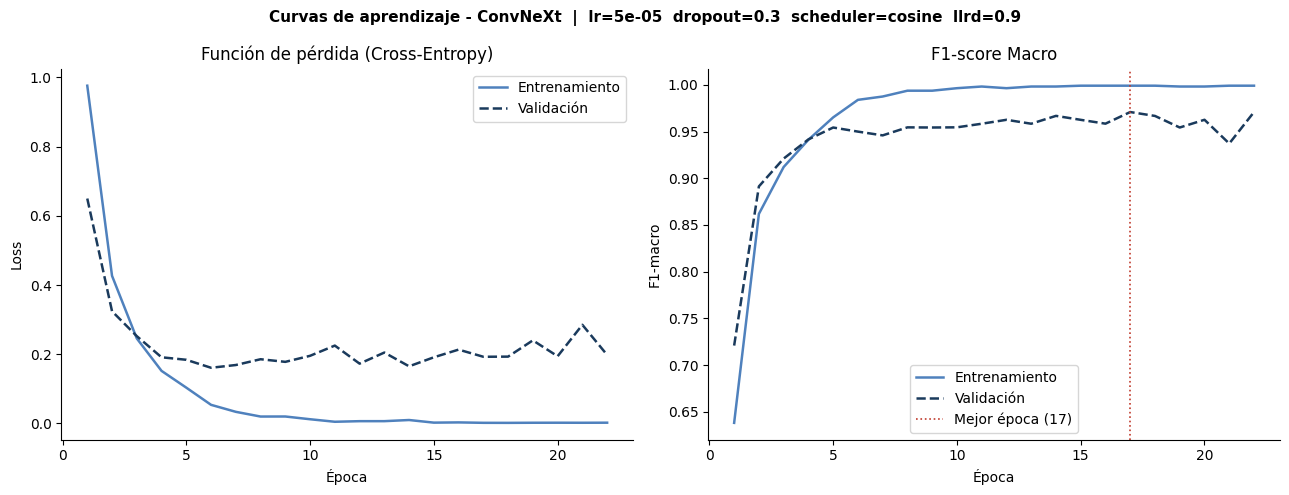

Curvas guardadas: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/convnext_curvas_aprendizaje.png


In [22]:
hist   = mejor_ensayo['historial']
epocas = range(1, len(hist['loss_train']) + 1)

COLOR_TRAIN = '#4f81bd'
COLOR_VAL   = '#1a3a5c'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Curvas de aprendizaje - ConvNeXt  |  "
    f"lr={mejor_ensayo['config']['lr']:.0e}  "
    f"dropout={mejor_ensayo['config']['dropout']}  "
    f"scheduler={mejor_ensayo['config']['scheduler']}  "
    f"llrd={mejor_ensayo['config']['llrd']}",
    fontsize=11, fontweight='bold'
)

# Pérdida
axes[0].plot(epocas, hist['loss_train'], color=COLOR_TRAIN, linewidth=1.8, label='Entrenamiento')
axes[0].plot(epocas, hist['loss_val'],   color=COLOR_VAL,   linewidth=1.8,
             label='Validación', linestyle='--')
axes[0].set_title('Función de pérdida (Cross-Entropy)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# F1-macro
axes[1].plot(epocas, hist['f1_train'], color=COLOR_TRAIN, linewidth=1.8, label='Entrenamiento')
axes[1].plot(epocas, hist['f1_val'],   color=COLOR_VAL,   linewidth=1.8,
             label='Validación', linestyle='--')
mejor_ep = hist['f1_val'].index(max(hist['f1_val'])) + 1
axes[1].axvline(mejor_ep, color='#c0392b', linestyle=':', linewidth=1.2,
                label=f'Mejor época ({mejor_ep})')
axes[1].set_title('F1-score Macro')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('F1-macro')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
ruta_curvas = DIR_PROYECTO / 'convnext_curvas_aprendizaje.png'
plt.savefig(ruta_curvas, dpi=150, bbox_inches='tight')
plt.show()
print(f"Curvas guardadas: {ruta_curvas}")


## Evaluación final sobre conjunto de prueba

In [23]:
modelo_final = construir_modelo(mejor_ensayo['config']['dropout'])
modelo_final.load_state_dict(mejor_ensayo['mejor_estado'])
modelo_final.eval()

loader_test = DataLoader(ds_test, batch_size=16, shuffle=False,
                         num_workers=2, pin_memory=True)

etiq_test, pred_test, prob_test, metricas_test = evaluar(modelo_final, loader_test)

print("=" * 58)
print("  Resultados Finales - Conjunto de Prueba (ConvNeXt)")
print("=" * 58)
print(f"  Accuracy global  : {metricas_test['accuracy']:.4f}  ({metricas_test['accuracy']*100:.2f}%)")
print(f"  F1-score macro   : {metricas_test['f1_macro']:.4f}")
print(f"  Precision macro  : {metricas_test['precision']:.4f}")
print(f"  Recall macro     : {metricas_test['recall']:.4f}")
if metricas_test.get('auc_roc'):
    print(f"  AUC-ROC (macro)  : {metricas_test['auc_roc']:.4f}")
print()
print("  F1-score por clase:")
for i, clase in enumerate(CLASES):
    print(f"    {clase:<15} {metricas_test['f1_clases'][i]:.4f}")
print()
print("  Reporte completo:")
print(classification_report(etiq_test, pred_test,
      target_names=CLASES, digits=4))


Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-base-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 1024]) vs model:torch.Size([4, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Resultados Finales - Conjunto de Prueba (ConvNeXt)
  Accuracy global  : 0.9417  (94.17%)
  F1-score macro   : 0.9414
  Precision macro  : 0.9418
  Recall macro     : 0.9417
  AUC-ROC (macro)  : 0.9917

  F1-score por clase:
    glioma          0.8889
    meningioma      0.9268
    notumor         0.9667
    pituitary       0.9833

  Reporte completo:
              precision    recall  f1-score   support

      glioma     0.9123    0.8667    0.8889        60
  meningioma     0.9048    0.9500    0.9268        60
     notumor     0.9667    0.9667    0.9667        60
   pituitary     0.9833    0.9833    0.9833        60

    accuracy                         0.9417       240
   macro avg     0.9418    0.9417    0.9414       240
weighted avg     0.9418    0.9417    0.9414       240



## Matriz de confusión

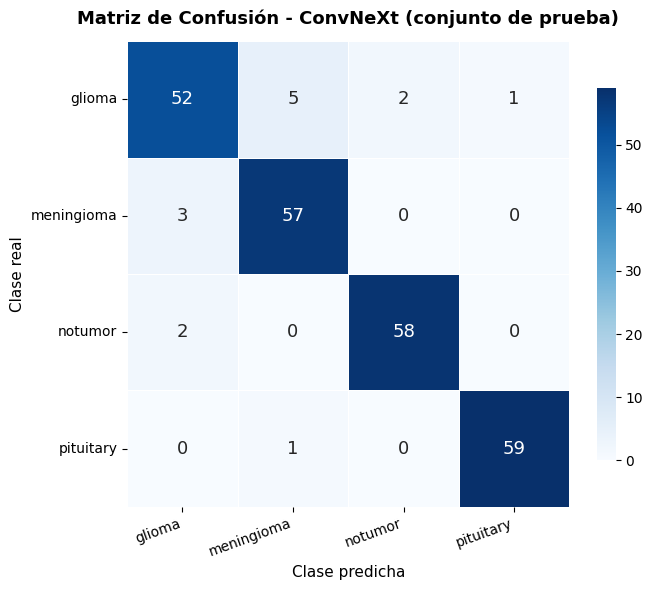

Matriz guardada: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/convnext_matriz_confusion.png


In [24]:
mc = confusion_matrix(etiq_test, pred_test)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    mc, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASES, yticklabels=CLASES,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 13},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Confusión - ConvNeXt (conjunto de prueba)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Clase predicha', fontsize=11)
ax.set_ylabel('Clase real', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

ruta_mc = DIR_PROYECTO / 'convnext_matriz_confusion.png'
plt.savefig(ruta_mc, dpi=150, bbox_inches='tight')
plt.show()
print(f"Matriz guardada: {ruta_mc}")


## Mapas de activación Grad-CAM

Capa Grad-CAM: ConvNextLayer (ultima capa, Etapa 4)


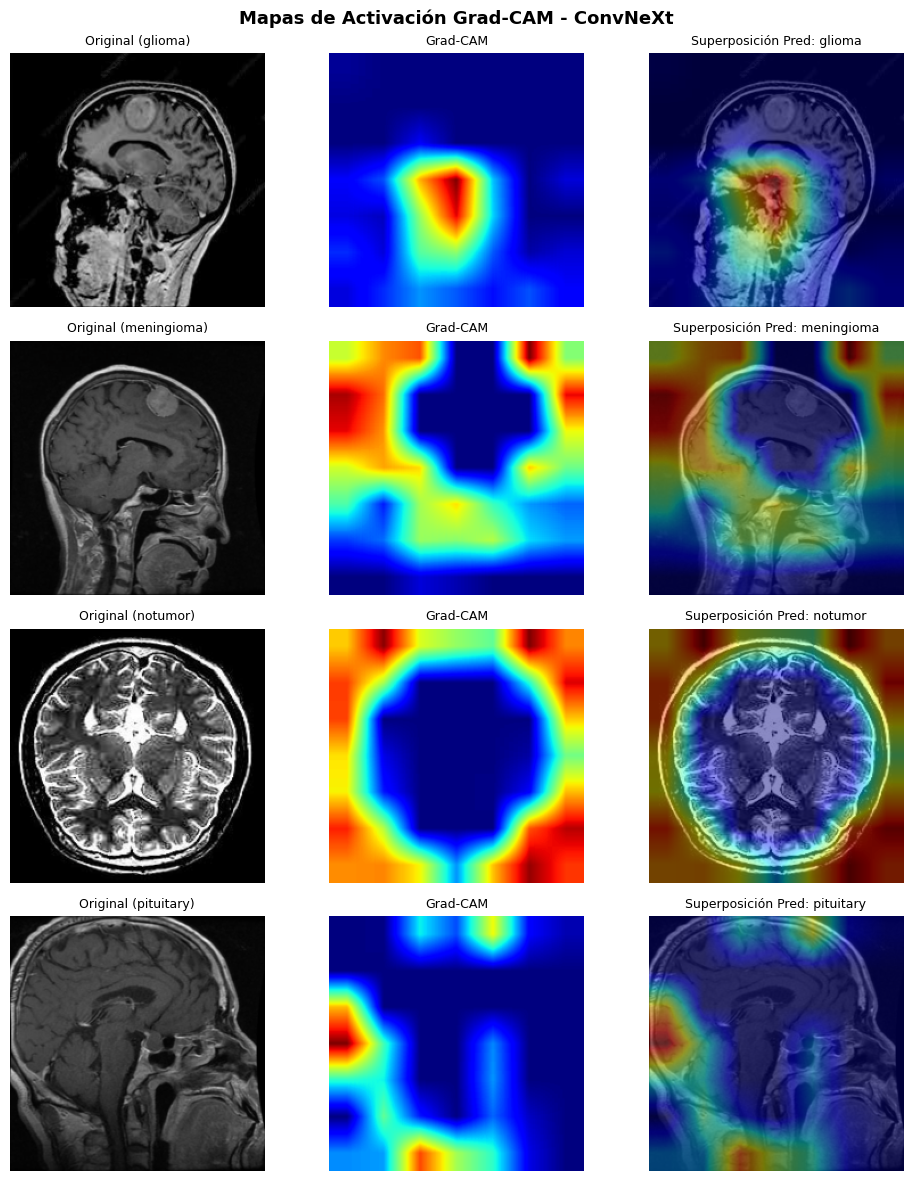

Grad-CAM guardado: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/convnext_grad_cam.png


In [26]:
class GradCAM:
    """Implementacion de Gradient-weighted Class Activation Mapping.

    Registra activaciones y gradientes de la capa objetivo mediante
    hooks de PyTorch, calcula el mapa de activacion ponderado por
    gradientes y lo redimensiona al tamaño de la imagen de entrada.
    """

    def __init__(self, modelo: nn.Module, capa_objetivo: nn.Module):
        self.modelo         = modelo
        self.activaciones   = None
        self.gradientes     = None

        # Hooks para capturar activaciones y gradientes
        self._hook_forward = capa_objetivo.register_forward_hook(
            lambda m, inp, out: setattr(self, 'activaciones', out.detach())
        )
        self._hook_backward = capa_objetivo.register_full_backward_hook(
            lambda m, grad_in, grad_out: setattr(self, 'gradientes', grad_out[0].detach())
        )

    def calcular(self, imagen_tensor: torch.Tensor, clase_idx: int) -> np.ndarray:
        """Calcula el mapa Grad-CAM para una imagen y clase dadas."""
        self.modelo.eval()
        imagen = imagen_tensor.unsqueeze(0).to(DEVICE)
        imagen.requires_grad_(True)

        salida = self.modelo(imagen)
        logits = salida.logits if hasattr(salida, 'logits') else salida

        self.modelo.zero_grad()
        logits[0, clase_idx].backward()

        # Pesos: media global de gradientes por canal
        pesos = self.gradientes.mean(dim=[0, 2, 3])

        # Mapa: combinacion lineal ponderada de activaciones
        mapa = torch.zeros(self.activaciones.shape[2:], device=DEVICE)
        for i, peso in enumerate(pesos):
            mapa += peso * self.activaciones[0, i]

        mapa = torch.relu(mapa).cpu().numpy()
        if mapa.max() > 0:
            mapa = (mapa - mapa.min()) / (mapa.max() - mapa.min() + 1e-8)
        return mapa

    def liberar(self):
        """Elimina los hooks para liberar memoria."""
        self._hook_forward.remove()
        self._hook_backward.remove()


def desnormalizar(tensor_img: torch.Tensor) -> np.ndarray:
    """Invierte la normalizacion ImageNet para visualizacion."""
    media = torch.tensor(MEDIA).view(3, 1, 1)
    desv  = torch.tensor(DESV).view(3, 1, 1)
    img   = tensor_img * desv + media
    return img.permute(1, 2, 0).clamp(0, 1).numpy()


# Seleccionar capa objetivo: ultima capa de la Etapa 4 de ConvNeXt
try:
    capa_objetivo = modelo_final.convnext.encoder.stages[-1].layers[-1]
    print(f"Capa Grad-CAM: {type(capa_objetivo).__name__} (ultima capa, Etapa 4)")
except AttributeError:
    capa_objetivo = list(modelo_final.modules())[-4]
    print(f"Capa Grad-CAM (fallback): {type(capa_objetivo).__name__}")

grad_cam = GradCAM(modelo_final, capa_objetivo)

# Visualizar 1 muestra correctamente clasificada por clase
fig, axes = plt.subplots(N_CLASES, 3, figsize=(10, N_CLASES * 3))
fig.suptitle('Mapas de Activación Grad-CAM - ConvNeXt',
             fontsize=13, fontweight='bold')

for fila, clase in enumerate(CLASES):
    indices_clase = [i for i, (_, e) in enumerate(ds_test.muestras)
                     if e == CLASE2IDX[clase]]
    muestra_encontrada = False

    for idx in indices_clase[:30]:
        img_t, etiq = ds_test[idx]
        with torch.no_grad():
            logits_check = modelo_final(
                img_t.unsqueeze(0).to(DEVICE)
            ).logits
        pred_idx = logits_check.argmax(1).item()

        if pred_idx == etiq:
            mapa = grad_cam.calcular(img_t, etiq)
            img_np = desnormalizar(img_t)

            # Redimensionar mapa al tamaño de la imagen
            mapa_pil = Image.fromarray((mapa * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR
            )
            mapa_resized = np.array(mapa_pil) / 255.0

            # Imagen original
            axes[fila][0].imshow(img_np)
            axes[fila][0].set_title(f'Original ({clase})', fontsize=9)
            axes[fila][0].axis('off')

            # Mapa Grad-CAM
            axes[fila][1].imshow(mapa_resized, cmap='jet', interpolation='bilinear')
            axes[fila][1].set_title('Grad-CAM', fontsize=9)
            axes[fila][1].axis('off')

            # Superposición
            mapa_rgb    = cm.jet(mapa_resized)[:, :, :3]
            overlay     = 0.55 * img_np + 0.45 * mapa_rgb
            axes[fila][2].imshow(overlay.clip(0, 1))
            axes[fila][2].set_title(f'Superposición Pred: {IDX2CLASE[pred_idx]}', fontsize=9)
            axes[fila][2].axis('off')

            muestra_encontrada = True
            break

    if not muestra_encontrada:
        for col in range(3):
            axes[fila][col].axis('off')
            axes[fila][col].set_title(f'({clase}: sin muestra correcta)', fontsize=8)

grad_cam.liberar()

plt.tight_layout()
ruta_gradcam = DIR_PROYECTO / 'convnext_grad_cam.png'
plt.savefig(ruta_gradcam, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM guardado: {ruta_gradcam}")


## Guardar Checkpoint y resultados en Drive

In [27]:
DIR_CHECKPOINTS = DIR_PROYECTO / 'checkpoints'
DIR_CHECKPOINTS.mkdir(exist_ok=True)
ruta_checkpoint = DIR_CHECKPOINTS / 'convnext_mejor_modelo.pth'
torch.save({
    'model_state_dict': mejor_ensayo['mejor_estado'],
    'config'          : mejor_ensayo['config'],
    'metricas_val'    : {'f1_macro': mejor_ensayo['mejor_f1_val']},
    'clases'          : CLASES,
    'clase2idx'       : CLASE2IDX,
}, ruta_checkpoint)
print(f"Checkpoint guardado: {ruta_checkpoint}")

resultados_json = {
    'modelo'           : 'facebook/convnext-base-224',
    'mejor_config'     : {k: v for k, v in mejor_ensayo['config'].items() if k != 'id'},
    'mejor_f1_val'     : round(mejor_ensayo['mejor_f1_val'], 6),
    'epocas_entrenadas': len(mejor_ensayo['historial']['loss_train']),
    'tiempo_total_seg' : mejor_ensayo['tiempo_seg'],
    'metricas_test'    : {
        'accuracy'    : round(metricas_test['accuracy'], 6),
        'f1_macro'    : round(metricas_test['f1_macro'], 6),
        'precision'   : round(metricas_test['precision'], 6),
        'recall'      : round(metricas_test['recall'], 6),
        'auc_roc'     : round(metricas_test['auc_roc'], 6) if metricas_test.get('auc_roc') else None,
        'f1_por_clase': {c: round(metricas_test['f1_clases'][i], 6)
                         for i, c in enumerate(CLASES)},
    },
    'historial_mejor_ensayo': mejor_ensayo['historial'],
    'resumen_ensayos': [
        {
            'id'        : r['id'],
            'lr'        : r['config']['lr'],
            'dropout'   : r['config']['dropout'],
            'scheduler' : r['config']['scheduler'],
            'llrd'      : r['config']['llrd'],
            'f1_val'    : round(r['mejor_f1_val'], 6),
            'tiempo_min': round(r['tiempo_seg'] / 60, 2),
        }
        for r in resultados_ensayos
    ],
}

ruta_resultados = DIR_PROYECTO / 'convnext_resultados.json'
with open(ruta_resultados, 'w', encoding='utf-8') as f:
    json.dump(resultados_json, f, indent=2, ensure_ascii=False)
print(f"Resultados guardados: {ruta_resultados}")


Checkpoint guardado: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/checkpoints/convnext_mejor_modelo.pth
Resultados guardados: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/convnext_resultados.json


## Resumen

In [28]:
print("=" * 60)
print("  Resumen Fine-Tuning ConvNeXt")
print("=" * 60)
print(f"  Modelo        : facebook/convnext-base-224")
print(f"  Mejor config  : lr={mejor_ensayo['config']['lr']:.0e}"
      f"  dropout={mejor_ensayo['config']['dropout']}"
      f"  scheduler={mejor_ensayo['config']['scheduler']}"
      f"  llrd={mejor_ensayo['config']['llrd']}")
print(f"  Epocas        : {len(mejor_ensayo['historial']['loss_train'])}")
print(f"  Tiempo total  : {mejor_ensayo['tiempo_seg']/60:.1f} min")
print()
print("  Metricas en conjunto de PRUEBA:")
print(f"    Accuracy    : {metricas_test['accuracy']*100:.2f}%")
print(f"    F1-macro    : {metricas_test['f1_macro']:.4f}")
print(f"    Precision   : {metricas_test['precision']:.4f}")
print(f"    Recall      : {metricas_test['recall']:.4f}")
if metricas_test.get('auc_roc'):
    print(f"    AUC-ROC     : {metricas_test['auc_roc']:.4f}")
print()
print("  Archivos generados en Drive:")
for archivo in ['convnext_curvas_aprendizaje.png',
                'convnext_matriz_confusion.png',
                'convnext_grad_cam.png',
                'convnext_resultados.json',
                'checkpoints/convnext_mejor_modelo.pth']:
    print(f"    {archivo}")


  Resumen Fine-Tuning ConvNeXt
  Modelo        : facebook/convnext-base-224
  Mejor config  : lr=5e-05  dropout=0.3  scheduler=cosine  llrd=0.9
  Epocas        : 22
  Tiempo total  : 25.2 min

  Metricas en conjunto de PRUEBA:
    Accuracy    : 94.17%
    F1-macro    : 0.9414
    Precision   : 0.9418
    Recall      : 0.9417
    AUC-ROC     : 0.9917

  Archivos generados en Drive:
    convnext_curvas_aprendizaje.png
    convnext_matriz_confusion.png
    convnext_grad_cam.png
    convnext_resultados.json
    checkpoints/convnext_mejor_modelo.pth
